# Day - 2: Normalization and Standardization

In [ ]:
! pip install pandas numpy scikit-learn matplotlib seaborn opencv-python

In [7]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt


# Normalization

## Min-Max Scaling: [0,1] range

In [2]:
image = cv2.imread('Kshitij.jpg')

In [4]:
normalized = image.astype('float32') / 255.0

print(normalized)
print(normalized.dtype)

[[[0.81960785 0.8666667  0.8745098 ]
  [0.81960785 0.8666667  0.8745098 ]
  [0.81960785 0.8666667  0.8745098 ]
  ...
  [0.8666667  0.87058824 0.8352941 ]
  [0.88235295 0.8862745  0.8509804 ]
  [0.85882354 0.8627451  0.827451  ]]

 [[0.81960785 0.8666667  0.8745098 ]
  [0.81960785 0.8666667  0.8745098 ]
  [0.81960785 0.8666667  0.8745098 ]
  ...
  [0.8666667  0.87058824 0.8352941 ]
  [0.8784314  0.88235295 0.84705883]
  [0.85882354 0.8627451  0.827451  ]]

 [[0.81960785 0.8666667  0.8745098 ]
  [0.81960785 0.8666667  0.8745098 ]
  [0.81960785 0.8666667  0.8745098 ]
  ...
  [0.8666667  0.87058824 0.8352941 ]
  [0.8745098  0.8784314  0.84313726]
  [0.85490197 0.85882354 0.8235294 ]]

 ...

 [[0.627451   0.75686276 0.8352941 ]
  [0.627451   0.75686276 0.8352941 ]
  [0.627451   0.75686276 0.8352941 ]
  ...
  [0.52156866 0.5254902  0.5176471 ]
  [0.5058824  0.50980395 0.5019608 ]
  [0.5019608  0.5058824  0.49803922]]

 [[0.5647059  0.6901961  0.78039217]
  [0.5764706  0.7019608  0.7921569 ]


In [5]:
min_val = np.min(normalized)
max_val = np.max(normalized)
print(min_val)
print(max_val)

0.0
1.0


In [ ]:
# Normalize to [-1,1]
normalized_neg1_1 = (image.astype('float32') / 127.5) - 1.0

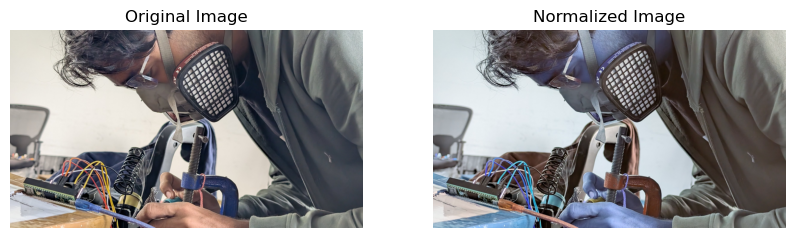

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(normalized)
ax[1].set_title('Normalized Image')
ax[1].axis('off')
plt.show()

## Z-score Standardization: mean=0, std=1

In [9]:
image_float = image.astype('float32')
mean = np.mean(image_float, axis=(0, 1), keepdims=True)
std = np.std(image_float, axis=(0, 1), keepdims=True)
standardized = (image_float - mean) / std

print(mean)
print(std)

[[[121.64598 122.01743 125.31765]]]
[[[64.58686 71.2093  75.39495]]]


In [10]:
standardized.mean()

np.float32(0.0014537825)

In [12]:
standardized.std()

np.float32(1.0005103)

## Image Net Standardization: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]

In [13]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225]) 

print(IMAGENET_MEAN)
print(IMAGENET_STD)

[0.485 0.456 0.406]
[0.229 0.224 0.225]


In [14]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) / 255.0  # Normalize to [0, 1]
normalized = (image_rgb - IMAGENET_MEAN) / IMAGENET_STD

print(normalized)

[[[1.70091617 1.83333333 1.83825708]
  [1.70091617 1.83333333 1.83825708]
  [1.70091617 1.83333333 1.83825708]
  ...
  [1.52966864 1.85084034 2.04740741]
  [1.59816765 1.92086835 2.11712418]
  [1.49541913 1.81582633 2.01254902]]

 [[1.70091617 1.83333333 1.83825708]
  [1.70091617 1.83333333 1.83825708]
  [1.70091617 1.83333333 1.83825708]
  ...
  [1.52966864 1.85084034 2.04740741]
  [1.5810429  1.90336134 2.09969499]
  [1.49541913 1.81582633 2.01254902]]

 [[1.70091617 1.83333333 1.83825708]
  [1.70091617 1.83333333 1.83825708]
  [1.70091617 1.83333333 1.83825708]
  ...
  [1.52966864 1.85084034 2.04740741]
  [1.56391814 1.88585434 2.0822658 ]
  [1.47829437 1.79831933 1.99511983]]

 ...

 [[1.52966864 1.34313725 0.98422658]
  [1.52966864 1.34313725 0.98422658]
  [1.52966864 1.34313725 0.98422658]
  ...
  [0.14256358 0.31022409 0.51363834]
  [0.07406456 0.24019608 0.44392157]
  [0.05693981 0.22268908 0.42649237]]

 [[1.28992208 1.04551821 0.70535948]
  [1.34129634 1.09803922 0.75764706]


## Preprocessing pipeline function

In [17]:
def preprocess_image(image, method='imagenet', resize=(224,224)):
    image_float = image.astype('float32') / 255.0  # Normalize to [0, 1]
    
    image = cv2.imread('Kshitij.jpg')
    if image is None:
        raise ValueError("Image not found or unable to read.")
    
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    if resize is not None:
        image = cv2.resize(image, resize)

    image = image.astype(np.float32)

    if method == 'imagenet':
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = (image / 255.0 - mean) / std

    elif method == 'zscore':
        mean = np.mean(image, axis=(0, 1), keepdims=True)
        std = np.std(image, axis=(0, 1), keepdims=True)
        image = (image - mean) / std

    return image

preprocessed_image = preprocess_image(image, method='imagenet', resize=(220, 224))
print(preprocessed_image)


[[[ 1.70091621  1.83333337  1.83825713]
  [ 1.70091621  1.83333337  1.83825713]
  [ 1.70091621  1.83333337  1.83825713]
  ...
  [ 1.30704689  1.62324935  1.82082794]
  [ 1.18717362  1.50070034  1.69882359]
  [ 1.47829442  1.79831937  1.99511986]]

 [[ 1.70091621  1.83333337  1.83825713]
  [ 1.70091621  1.83333337  1.83825713]
  [ 1.70091621  1.83333337  1.83825713]
  ...
  [ 1.11867461  1.44817933  1.62910681]
  [ 1.52966868  1.85084037  2.04740744]
  [ 1.28992214  1.62324935  1.82082794]]

 [[ 1.70091621  1.83333337  1.83825713]
  [ 1.70091621  1.83333337  1.83825713]
  [ 1.70091621  1.83333337  1.83825713]
  ...
  [ 0.98167659  1.29061631  1.48967327]
  [ 1.3755459   1.69327735  1.89054471]
  [ 1.25567263  1.62324935  1.80339874]]

 ...

 [[ 1.46116967  1.27310931  0.9319391 ]
  [ 1.52966868  1.34313732  1.03651426]
  [ 1.52966868  1.36064432  1.03651426]
  ...
  [ 0.19393796  0.36274522  0.49620928]
  [ 0.09118944  0.25770321  0.39163399]
  [-0.62805031 -0.42506999 -0.25324615]]

 [

# Data Augmentation

## Flip Transformations

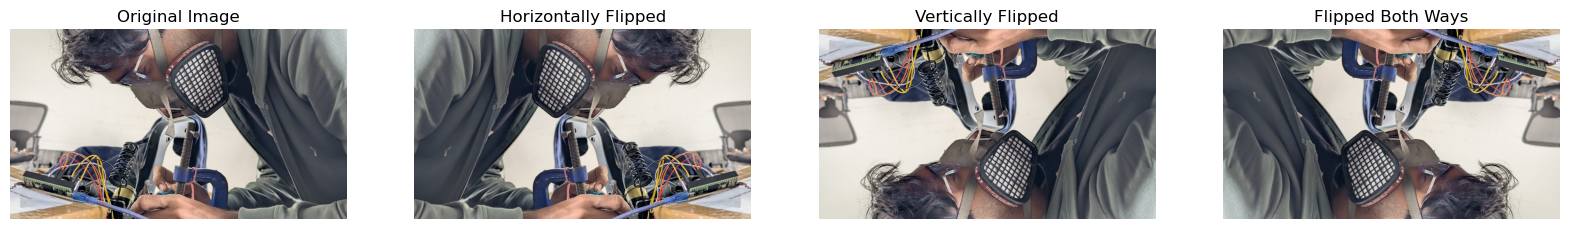

In [18]:
flipped_horizontally = cv2.flip(image, 1)  # Horizontal flip
flipped_vertically = cv2.flip(image, 0)    # Vertical flip
flipped_both = cv2.flip(image, -1)         # Both horizontal and vertical flip

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(flipped_horizontally, cv2.COLOR_BGR2RGB))
ax[1].set_title('Horizontally Flipped')
ax[1].axis('off')
ax[2].imshow(cv2.cvtColor(flipped_vertically, cv2.COLOR_BGR2RGB))
ax[2].set_title('Vertically Flipped')
ax[2].axis('off')
ax[3].imshow(cv2.cvtColor(flipped_both, cv2.COLOR_BGR2RGB))
ax[3].set_title('Flipped Both Ways')
ax[3].axis('off')
plt.show()

## Rotation Transformations

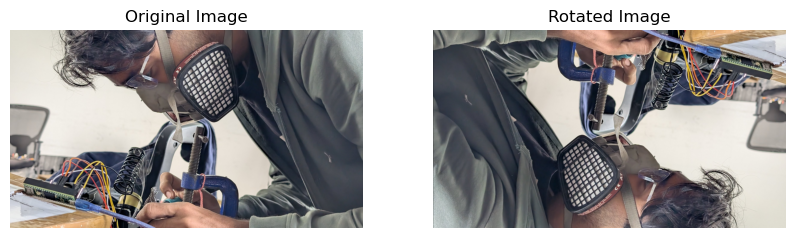

In [20]:
center = (image.shape[1] // 2, image.shape[0] // 2)
angle = 180
scale = 1.0

rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale) 
rotated_image = cv2.warpAffine(image, rotation_matrix, (image.shape[1], image.shape[0]))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(rotated_image, cv2.COLOR_BGR2RGB))
ax[1].set_title('Rotated Image')
ax[1].axis('off')
plt.show()

## Scaling and Zooming

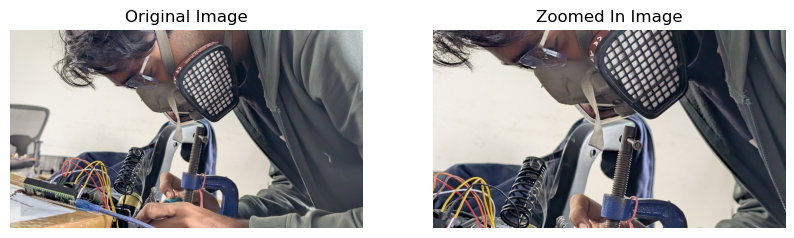

In [21]:
scale = 1.5
scaled = cv2.resize(image, None, fx=scale, fy=scale, interpolation=cv2.INTER_LINEAR)

# Cropping back to original size
start_x = (scaled.shape[1] - image.shape[1]) // 2
start_y = (scaled.shape[0] - image.shape[0]) // 2
zoomed_in = scaled[start_y:start_y + image.shape[0], start_x:start_x + image.shape[1]]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(zoomed_in, cv2.COLOR_BGR2RGB))
ax[1].set_title('Zoomed In Image')
ax[1].axis('off')
plt.show()

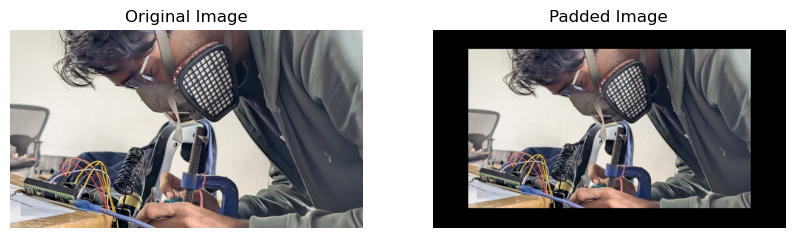

In [23]:
scale = 0.8
scaled_down = cv2.resize(image, None, fx=scale, fy=scale, interpolation=cv2.INTER_LINEAR)

pad_y = (image.shape[0] - scaled_down.shape[0]) // 2
pad_x = (image.shape[1] - scaled_down.shape[1]) // 2
padded_image = cv2.copyMakeBorder(scaled_down, pad_y, pad_y, pad_x, pad_x, cv2.BORDER_CONSTANT, value=[0, 0, 0])

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(padded_image, cv2.COLOR_BGR2RGB))
ax[1].set_title('Padded Image')
ax[1].axis('off')
plt.show()

In [24]:
padded_image.shape

(1330, 2363, 3)

In [25]:
image.shape

(1330, 2364, 3)

## Translation

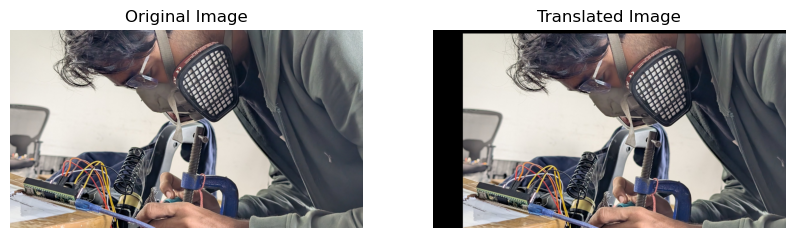

In [ ]:
tx = 200  # Translate 200 pixels right
ty = 30  # Translate 30 pixels down

# x' = 1*x + 0*y + tx
# y' = 0*x + 1*y + ty
translation_matrix = np.float32([[1, 0, tx], [0, 1, ty]])
translated_image = cv2.warpAffine(image, translation_matrix, (image.shape[1], image.shape[0]))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(translated_image, cv2.COLOR_BGR2RGB))
ax[1].set_title('Translated Image')
ax[1].axis('off')
plt.show()

## Shearing

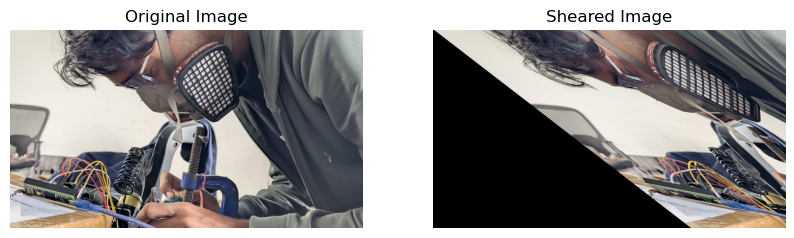

In [ ]:
# x' = a*x + b*y + c
# y' = shear*x + 1*y + ty

shear = 1.3  # Shear factor
shear_matrix = np.float32([[1, shear, 0], [0, 1, 0]])
sheared_image = cv2.warpAffine(image, shear_matrix, (image.shape[1], image.shape[0]))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(sheared_image, cv2.COLOR_BGR2RGB))
ax[1].set_title('Sheared Image')
ax[1].axis('off')
plt.show()
                                                                 

## Color augmentations

In [31]:
# Brightness adjustment

brightness_factor = 30
brighter = np.clip(image + brightness_factor, 0, 255).astype(np.uint8)

print(brighter)

[[[239 251 253]
  [239 251 253]
  [239 251 253]
  ...
  [251 252 243]
  [255   0 247]
  [249 250 241]]

 [[239 251 253]
  [239 251 253]
  [239 251 253]
  ...
  [251 252 243]
  [254 255 246]
  [249 250 241]]

 [[239 251 253]
  [239 251 253]
  [239 251 253]
  ...
  [251 252 243]
  [253 254 245]
  [248 249 240]]

 ...

 [[190 223 243]
  [190 223 243]
  [190 223 243]
  ...
  [163 164 162]
  [159 160 158]
  [158 159 157]]

 [[174 206 229]
  [177 209 232]
  [181 213 236]
  ...
  [161 164 162]
  [161 164 162]
  [160 163 161]]

 [[172 204 227]
  [175 207 230]
  [179 211 234]
  ...
  [161 164 162]
  [161 164 162]
  [160 163 161]]]


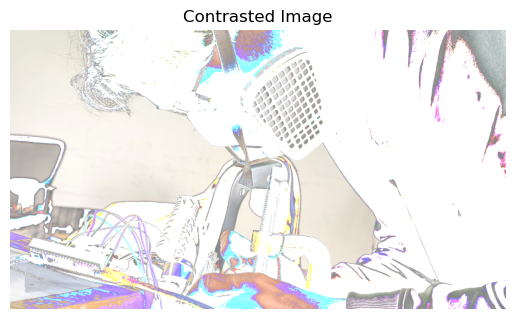

In [ ]:
contrast_factor = 1.1
contrasted1 = np.clip(image * contrast_factor, 0, 255).astype(np.uint8)
contrasted = np.clip(128 + contrast_factor * (image - 128), 0, 255).astype(np.uint8)

plt.imshow(cv2.cvtColor(contrasted, cv2.COLOR_BGR2RGB))
plt.title('Contrasted Image')
plt.axis('off')
plt.show()

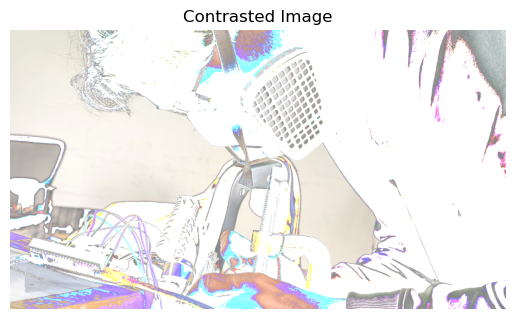

In [39]:
contrasted = np.clip(128 + contrast_factor * (image - 128), 0, 255).astype(np.uint8)

plt.imshow(cv2.cvtColor(contrasted, cv2.COLOR_BGR2RGB))
plt.title('Contrasted Image')
plt.axis('off')
plt.show()

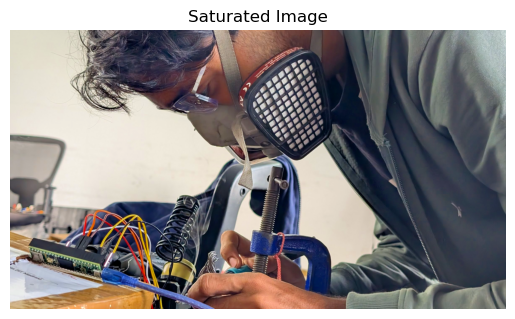

In [41]:
# Saturation adjustment
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV).astype('float32')
saturation_scale = 1.5
hsv_image[:, :, 1] = np.clip(hsv_image[:, :, 1] * saturation_scale, 0, 255)
saturated_image = cv2.cvtColor(hsv_image.astype('uint8'), cv2.COLOR_HSV2RGB)

plt.imshow(saturated_image)
plt.title('Saturated Image')
plt.axis('off')
plt.show()

## Augmentation pipeline function

In [ ]:
def augmentation_pipeline(image, augmentation_probability = 0.5):
    augmented_image = image.copy()
    
    if np.random.rand() < augmentation_probability:
        # Random horizontal flip
        if np.random.rand() < 0.5:
            augmented_image = cv2.flip(augmented_image, 1)
        
        # Random rotation
        angle = np.random.uniform(-30, 30)
        center = (augmented_image.shape[1] // 2, augmented_image.shape[0] // 2)
        rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
        augmented_image = cv2.warpAffine(augmented_image, rotation_matrix, (augmented_image.shape[1], augmented_image.shape[0]))
        
        # Random brightness adjustment
        brightness_factor = np.random.randint(-50, 50)
        augmented_image = np.clip(augmented_image + brightness_factor, 0, 255).astype(np.uint8)
        
        # Random contrast adjustment
        contrast_factor = np.random.uniform(0.8, 1.2)
        augmented_image = np.clip(128 + contrast_factor * (augmented_image - 128), 0, 255).astype(np.uint8)
    
    return augmented_image

# Classical CV techniques

# Edge Detection

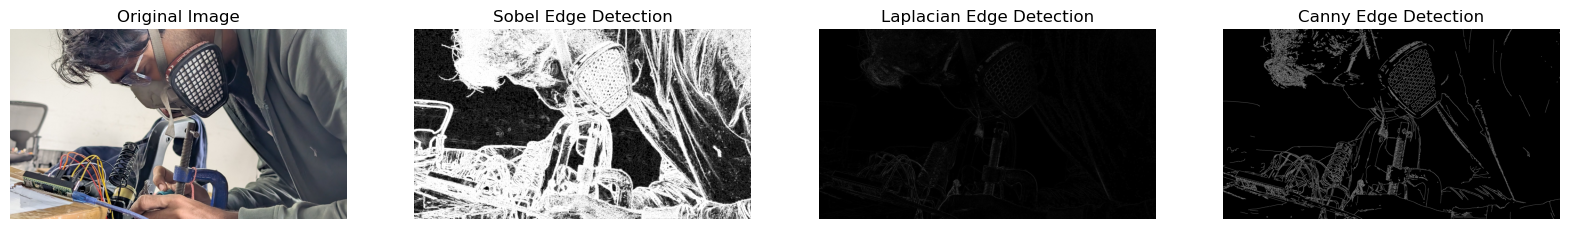

In [43]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 1. Sobel Edge Detection
sobel_x = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(gray_image, cv2.CV_64F, 0, 1, ksize=5)

magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
magnitude = np.clip(magnitude, 0, 255).astype(np.uint8)
# magnitude = np.uint8(magnitude)

# 2. Laplacian Edge Detection
laplacian = cv2.Laplacian(gray_image, cv2.CV_64F)
laplacian = np.clip(laplacian, 0, 255).astype(np.uint8)
# laplacian = np.uint8(laplacian)

# 3. Canny Edge Detection
canny_edges = cv2.Canny(gray_image, 100, 200)

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(magnitude, cmap='gray')
ax[1].set_title('Sobel Edge Detection')
ax[1].axis('off')
ax[2].imshow(laplacian, cmap='gray')
ax[2].set_title('Laplacian Edge Detection')
ax[2].axis('off')
ax[3].imshow(canny_edges, cmap='gray')
ax[3].set_title('Canny Edge Detection')
ax[3].axis('off')
plt.show()

## Contour Detection and analysis

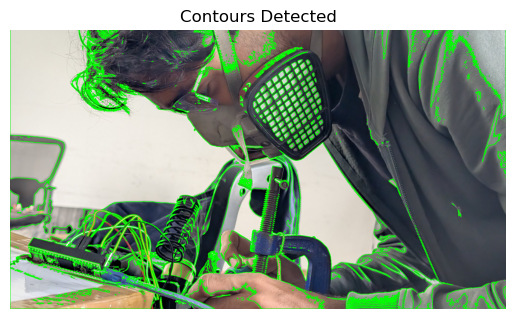

In [51]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
ret, binary_image = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)
# ret, binary_image = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

contours, hierarchy = cv2.findContours(binary_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

result = image.copy()
cv2.drawContours(result, contours, -1, (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title('Contours Detected')
plt.axis('off')
plt.show()

## Filter contours based on area, shape, etc.

In [52]:
large_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > 1000]
print(f"Total contours: {len(contours)}, Large contours: {len(large_contours)}")

Total contours: 3051, Large contours: 27


Contour Area: 18385.5, Perimeter: 3824.4520020484924
Contour Area: 12563.5, Perimeter: 1221.4183886051178
Contour Area: 1857.0, Perimeter: 393.7056235074997
Contour Area: 1295.0, Perimeter: 458.9848439693451
Contour Area: 2574.5, Perimeter: 224.81118214130402
Contour Area: 9572.0, Perimeter: 1114.513839483261
Contour Area: 3364.5, Perimeter: 303.86500453948975
Contour Area: 2222.0, Perimeter: 541.3868631124496
Contour Area: 1635.0, Perimeter: 369.07820773124695
Contour Area: 154223.0, Perimeter: 4999.746706604958
Contour Area: 39013.5, Perimeter: 827.7472547292709
Contour Area: 4157.5, Perimeter: 755.1686081886292
Contour Area: 6029.0, Perimeter: 977.7442893981934
Contour Area: 2810.0, Perimeter: 626.9848430156708
Contour Area: 59798.0, Perimeter: 3234.3069006204605
Contour Area: 2920.0, Perimeter: 621.4457385540009
Contour Area: 2449.0, Perimeter: 386.5929266214371
Contour Area: 46388.5, Perimeter: 3219.9364047050476
Contour Area: 875837.5, Perimeter: 29307.124925136566
Contour Area: 

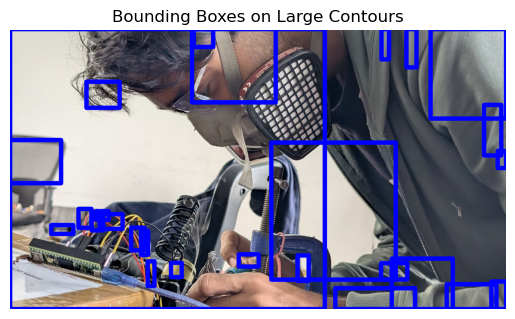

In [54]:
result_boxes = image.copy()
for cnt in large_contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(result_boxes, (x, y), (x + w, y + h), (255, 0, 0), 20)

    # Get contour area and perimeter
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    print(f"Contour Area: {area}, Perimeter: {perimeter}")

plt.imshow(cv2.cvtColor(result_boxes, cv2.COLOR_BGR2RGB))
plt.title('Bounding Boxes on Large Contours')
plt.axis('off')
plt.show()

# Hough Transform for Line Detection

Detected 54 lines.


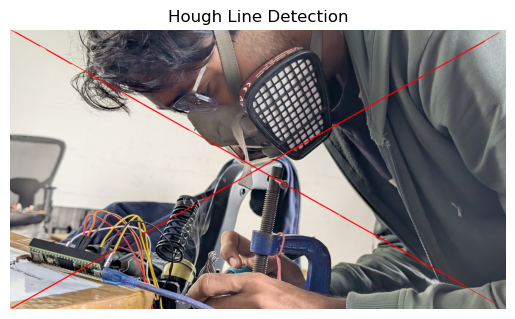

In [58]:
line_img = np.zeros(image.shape, dtype=np.uint8)
cv2.line(line_img, (0, 0), (image.shape[1], image.shape[0]), (255, 0, 0), 2)
cv2.line(line_img, (image.shape[1], 0), (0, image.shape[0]), (0, 255, 0), 2)

gray_lines = cv2.cvtColor(line_img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray_lines, 50, 150, apertureSize=3)

# Hough line transform
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=100, minLineLength=50, maxLineGap=10)

result_hough = image.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(result_hough, (x1, y1), (x2, y2), (0, 0, 255), 2)
    print(f"Detected {len(lines)} lines.")

plt.imshow(cv2.cvtColor(result_hough, cv2.COLOR_BGR2RGB))
plt.title('Hough Line Detection')
plt.axis('off')
plt.show()

## Hough Transform for Circle Detection

Detected 3 circles.


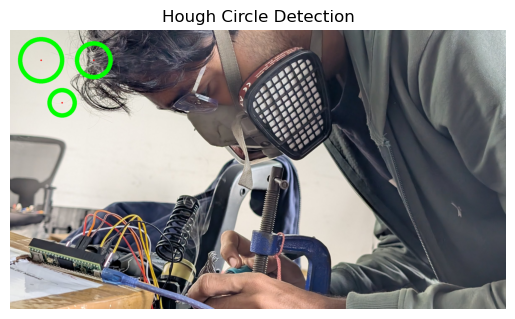

In [60]:
circle_img = np.zeros(image.shape, dtype=np.uint8)
cv2.circle(circle_img, (150, 150), 100, (255, 0, 0), 2)
cv2.circle(circle_img, (400, 150), 80, (0, 255, 0), 2)
cv2.circle(circle_img, (250, 350), 60, (0, 0, 255), 2)

gray_circles = cv2.cvtColor(circle_img, cv2.COLOR_BGR2GRAY)
blurred = cv2.medianBlur(gray_circles, 5)

circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, dp=1.2, minDist=50, param1=50, param2=30, minRadius=30, maxRadius=120)

result_circles = image.copy()
if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        # draw the outer circle
        cv2.circle(result_circles, (i[0], i[1]), i[2], (0, 255, 0), 20)
        # draw the center of the circle
        cv2.circle(result_circles, (i[0], i[1]), 2, (0, 0, 255), 3)
    print(f"Detected {len(circles[0])} circles.")

plt.imshow(cv2.cvtColor(result_circles, cv2.COLOR_BGR2RGB))
plt.title('Hough Circle Detection')
plt.axis('off')
plt.show()

## ORB feature detection and matching

Full form: ORB: Oriented FAST and Rotated BRIEF

In [63]:
orb = cv2.ORB_create()

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
keypoints, descriptors = orb.detectAndCompute(gray, None)

print(f"Detected {len(keypoints)} keypoints.")
if descriptors is not None:
    print(f"Descriptor shape: {descriptors.shape}")

Detected 500 keypoints.
Descriptor shape: (500, 32)


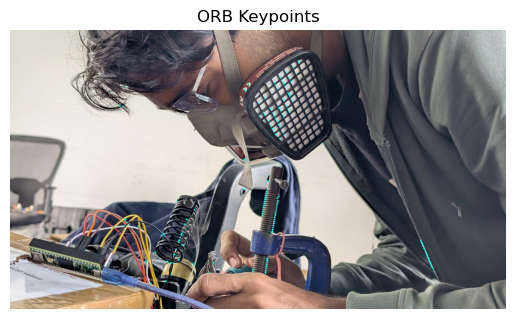

In [65]:
result_orb = cv2.drawKeypoints(image, keypoints, None, color=(240, 255, 0), flags=0)
plt.imshow(cv2.cvtColor(result_orb, cv2.COLOR_BGR2RGB))
plt.title('ORB Keypoints')
plt.axis('off')
plt.show()

## Template Matching

Max correlation value: 0.998323917388916 at location: (100, 100)


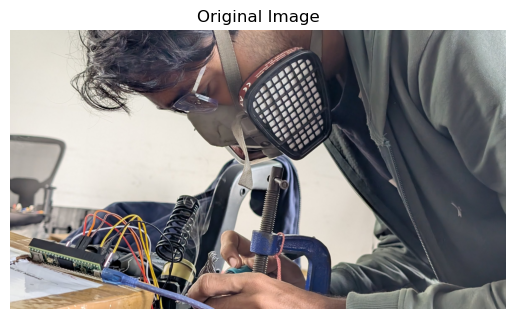

In [68]:
tempate = gray[100:200+50, 100:100+50]
template_height, template_width = tempate.shape

result_match = cv2.matchTemplate(gray, tempate, cv2.TM_CCOEFF_NORMED)

min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result_match)

print(f"Max correlation value: {max_val} at location: {max_loc}")

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.show()

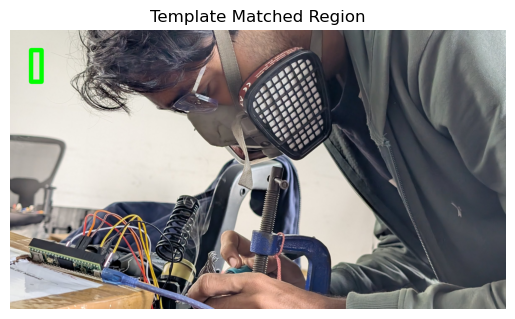

In [69]:
# Draw rectangle around matched region

top_left = max_loc
bottom_right = (top_left[0] + template_width, top_left[1] + template_height)
matched_image = image.copy()
cv2.rectangle(matched_image, top_left, bottom_right, (0, 255, 0), 20)
plt.imshow(cv2.cvtColor(matched_image, cv2.COLOR_BGR2RGB))
plt.title('Template Matched Region')
plt.axis('off')
plt.show()


## Face detection using Haar Cascades

Classical face detection method using pre-trained Haar Cascade classifiers
It:
1. Loads a pre-trained Haar Cascade classifier for face detection - loads pretrained face and eye detectors
2. check if they are loaded correctly
3. creares a dummy random image
4. runs the face detection on the image
5. draws rectangles around detected faces and eyes

In [70]:
# Face detection using Haar Cascades
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Loading eye detector
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

print("Face Cascade loaded:", not face_cascade.empty())

Face Cascade loaded: True


In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

print(f"Detected {len(faces)} faces.")

Detected 0 faces.


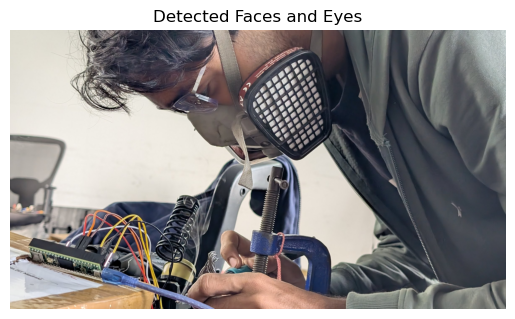

In [72]:
# Draw rectangle around matched region
result_faces = image.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(result_faces, (x, y), (x + w, y + h), (255, 0, 0), 20)
    cv2.putText(result_faces, 'Face', (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

    # Detect eyes within the face region
    roi_gray = gray[y:y + h, x:x + w]
    roi_color = result_faces[y:y + h, x:x + w]
    eyes = eye_cascade.detectMultiScale(roi_gray)

plt.imshow(cv2.cvtColor(result_faces, cv2.COLOR_BGR2RGB))
plt.title('Detected Faces and Eyes')
plt.axis('off')
plt.show()

In [ ]:
# Real tijme face detection using webcam

def detect_faces_webcam():
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

    cap = cv2.VideoCapture(0)

    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
            cv2.putText(frame, 'Face', (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

        cv2.imshow('Webcam Face Detection', frame)
        frame_count += 1

        if cv2.waitKey(1) & 0xFF == ord('q') or frame_count >= 100:
            break